In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima.arima import auto_arima

In [8]:
df = pd.read_csv('../data/AEP_hourly.csv', index_col='Datetime', parse_dates=True)
df.head()

,AEP_MW
Datetime,
2004-12-31 01:00:00,13478.0
2004-12-31 02:00:00,12865.0
2004-12-31 03:00:00,12577.0
2004-12-31 04:00:00,12517.0
2004-12-31 05:00:00,12670.0


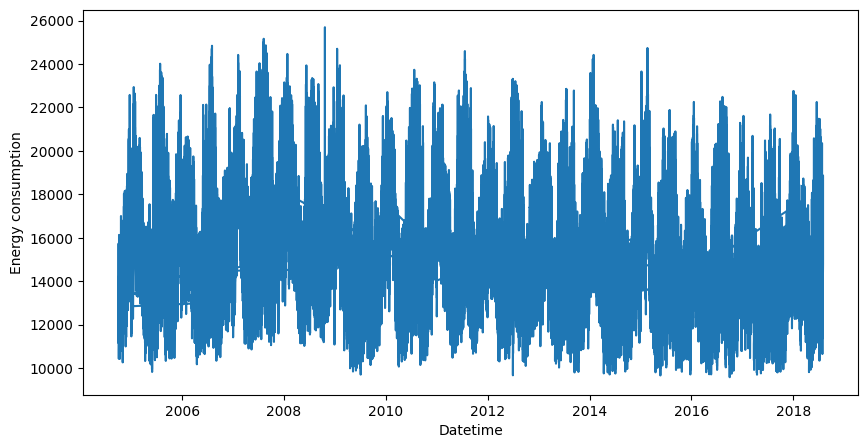

In [9]:
#Plot the dataset
plt.figure(figsize=(10,5))
plt.plot(df)
plt.xlabel('Datetime')
plt.ylabel('Energy consumption')
plt.show()

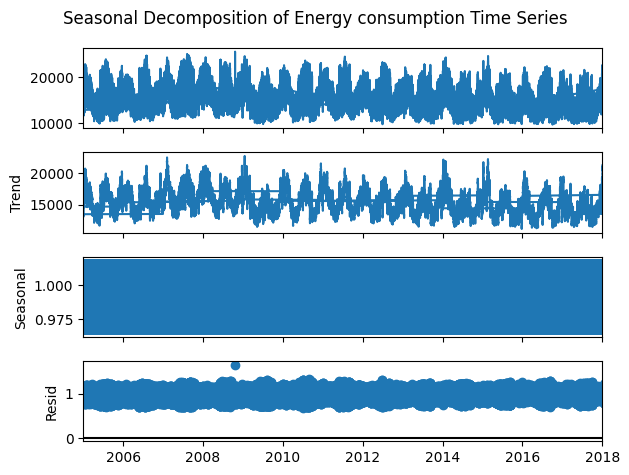

In [15]:
result = seasonal_decompose(
    df, model='multiplicative', extrapolate_trend='freq', period=24)
result.plot()
plt.suptitle('Seasonal Decomposition of Energy consumption Time Series')
plt.tight_layout()
plt.show()

In [4]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(Dataframe, difference=False, graph=False):
    # Check for stationarity
    result = adfuller(Dataframe[Dataframe.columns[-1]])
    print(f'ADF Statistic : {result[0]}')
    print(f'P_Value : {result[1]}')
    if result[1] <= 0.05:
        print('Data is not stationary')
        if difference:
            print('Differencing the dataset')
            Dataframe = Dataframe.diff().dropna()
            result = adfuller(Dataframe[Dataframe.columns[-1]])
            print(f'Diff dataset, ADF Statistic : {result[0]}')
            print(f'Diff dataset, P_Value : {result[1]}')
            if graph:
                plt.figure(figsize=(10,5))
                plt.plot(Dataframe)
                plt.title('differenced dataset')
                plt.xlabel('Datetime')
                plt.ylabel('Energy consumption')
                plt.show()
    else:
        print('Data is stationary')

    return Dataframe

In [5]:
df = check_stationarity(df, True, False)

ADF Statistic : -16.44681210468672
P_Value : 2.3990113240021306e-29
Data is not stationary
Differencing the dataset
Diff dataset, ADF Statistic : -45.05152316790394
Diff dataset, P_Value : 0.0


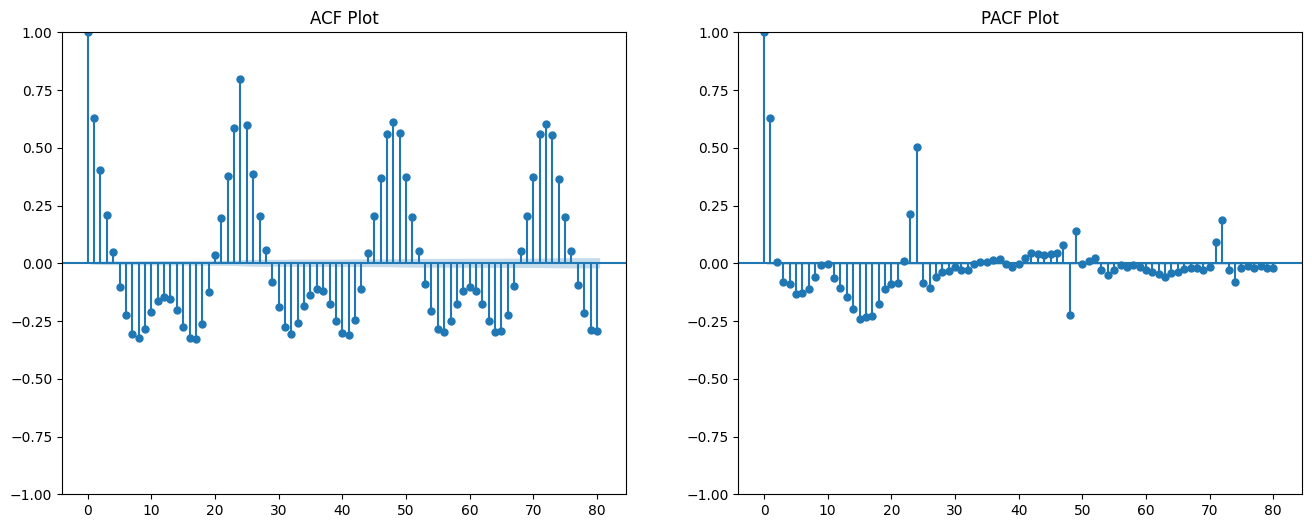

In [6]:
# Plot ACF and PACF to visualize the optimal lag
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ACF plot (autocorrelation)
plot_acf(df, ax=axes[0], lags=80)
axes[0].set_title('ACF Plot')

# PACF plot (partial autocorrelation)
plot_pacf(df, ax=axes[1], lags=80, method='ywm')
axes[1].set_title('PACF Plot')

plt.show()

# ARIMA model
AR - AutoRegressive
I - Integrated
MA - Moving Average

In [10]:
train, valid, test = np.split(df, [int(0.6*len(df)),int(0.8*len(df))])

/home/iprabhsidhu/EnergyPrediction/venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [12]:
sample = train['AEP_MW'].iloc[-20000:]

model = auto_arima(
    sample,
    seasonal=False,
    trace=True,
    stepwise=True
)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=301042.219, Time=20.59 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=314324.726, Time=0.41 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=303835.172, Time=0.62 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=306971.822, Time=3.58 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=314322.728, Time=0.29 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=303737.225, Time=2.28 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=303780.667, Time=12.59 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=301399.899, Time=24.81 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=300943.478, Time=28.04 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=303698.159, Time=6.99 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=300223.414, Time=41.20 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=300181.366, Time=41.37 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=301172.149, Time=32.15 sec
 ARIMA(5,1,3)(0,0,0)[0] intercept   : AIC=300166.446, Time=38.32 s

/home/iprabhsidhu/EnergyPrediction/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/home/iprabhsidhu/EnergyPrediction/venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


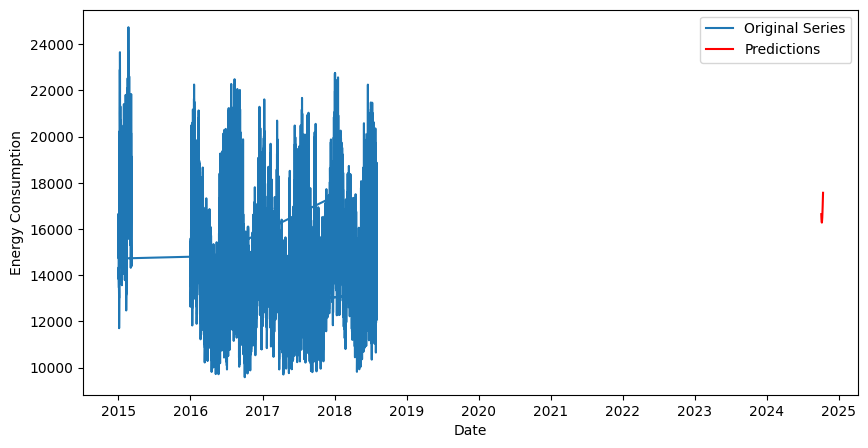

In [14]:
# Make predictions
predictions = model.predict(steps=5)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test, label='Original Series')
plt.plot(predictions, label='Predictions', color='red')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Energy Consumption')
plt.show()

In [15]:
print(predictions.head(100))

20000    16644.281204
20001    16418.284054
20002    16315.788491
20003    16277.630630
20004    16359.895447
20005    16493.360149
20006    16722.302883
20007    16971.732294
20008    17279.027280
20009    17568.531584
dtype: float64


In [16]:
print(test)

                      AEP_MW
Datetime                    
2015-03-07 09:00:00  18343.0
2015-03-07 10:00:00  17768.0
2015-03-07 11:00:00  17163.0
2015-03-07 12:00:00  16433.0
2015-03-07 13:00:00  15798.0
...                      ...
2018-01-01 20:00:00  21089.0
2018-01-01 21:00:00  20999.0
2018-01-01 22:00:00  20820.0
2018-01-01 23:00:00  20415.0
2018-01-02 00:00:00  19993.0

[24255 rows x 1 columns]
